In [1]:

import sys

sys.path.append(r"C:\Users\floot\Florian's Laptop\ESILV\CDR\CoupeDeRobotique\common")

from math import cos, sin, radians

from geometry import (
    Point,
    MultiPoint,
    Polygon,
    MultiPolygon,
    LineString,
    BufferCapStyle,
    BufferJoinStyle,
    Geometry,
    create_straight_rectangle,
    prepare,
    distance,

    OrientedPoint,
    nearest_points,
    box
)
from logger import Logger, LogLevels
import numpy as np


from arena import (
    # Enums
    ZoneType,
    ZoneAccessibility,
    # Zones
    BaseArenaZone,
    EnemyZone,
    AllyZone,
    StuffZone,
    BlueReservedZone,
    YellowReservedZone,
    BorderZone,
    ForbiddenZone,
    
    BaseArena,
)


15:59:27.899359 -> [GridManager ]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   


In [2]:
logger_arena = Logger(
    identifier="BaseArena",
    decorator_level=LogLevels.INFO,
    print_log_level=LogLevels.DEBUG,
    file_log_level=LogLevels.DEBUG,
)
logger_grid_manager = Logger(
        identifier="GridManager",
        decorator_level=LogLevels.INFO,
        print_log_level=LogLevels.DEBUG,
        file_log_level=LogLevels.DEBUG,
    )

arena = BaseArena(
    logger_arena,
    width=300,
    height=200,
    border_buffer=2,
    obstacle_buffer=1,
    zones=[],
    chunk_size=5,
    forbidden_cover_threshold=0.1,
    grid_manager_logger=logger_grid_manager,
)

15:59:27.930668 -> [ BaseArena  ]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
15:59:27.931670 -> [GridManager ]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
15:59:27.932668 -> [ BaseArena  ]  WARNING   | The border buffer is not a multiple of the chunk size -> the not walkable area will not be aligned with the grid
15:59:27.932668 -> [ BaseArena  ]  WARNING   | The obstacle buffer is not a multiple of the chunk size -> the not walkable area will not be aligned with the grid
15:59:27.933666 -> [ BorderZone ]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
15:59:28.116666 -> [GridManager ]   DEBUG    | Function `__mark_zone` executed in 0.176490 seconds.
15:59:28.117667 -> [GridManager ]   DEBUG    | Function `add_forbidden_static_zone` executed in 0.177541 seconds.
15:59:28.118667 -> [  AllyZone  ]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
15:59:28.119693 

In [3]:
import time
for i in range(10):
    arena.enemy_zone.update("", [], [Point(10+i*3, 10+i)])
    print(arena.enemy_zone)
    time.sleep(0.25)

ZoneType.FORBIDDEN: POINT (9.999999999999998 10.000000000000002) -> ZoneAccessibility.FORBIDDEN, ally visits: 0, enemy visits: 0, last update: 0.0 Speed: 0, Direction: (0, 0)
15:59:28.380378 -> [ BaseArena  ]   DEBUG    | Enemy visited ZoneType.FORBIDDEN zone
ZoneType.FORBIDDEN: POINT (36.71708245126284 18.905694150420945) -> ZoneAccessibility.FORBIDDEN, ally visits: 0, enemy visits: 0, last update: 0.0 Speed: 12.533703736854122, Direction: (0.9486832980505138, 0.31622776601683794)
15:59:28.634582 -> [ BaseArena  ]   DEBUG    | Enemy visited ZoneType.FORBIDDEN zone
ZoneType.FORBIDDEN: POINT (39.717082451262826 19.90569415042095) -> ZoneAccessibility.FORBIDDEN, ally visits: 0, enemy visits: 0, last update: 0.0 Speed: 12.462694837546705, Direction: (0.9486832980505138, 0.31622776601683794)
15:59:28.887900 -> [ BaseArena  ]   DEBUG    | Enemy visited ZoneType.FORBIDDEN zone
ZoneType.FORBIDDEN: POINT (42.71708245126286 20.90569415042095) -> ZoneAccessibility.FORBIDDEN, ally visits: 0, enem

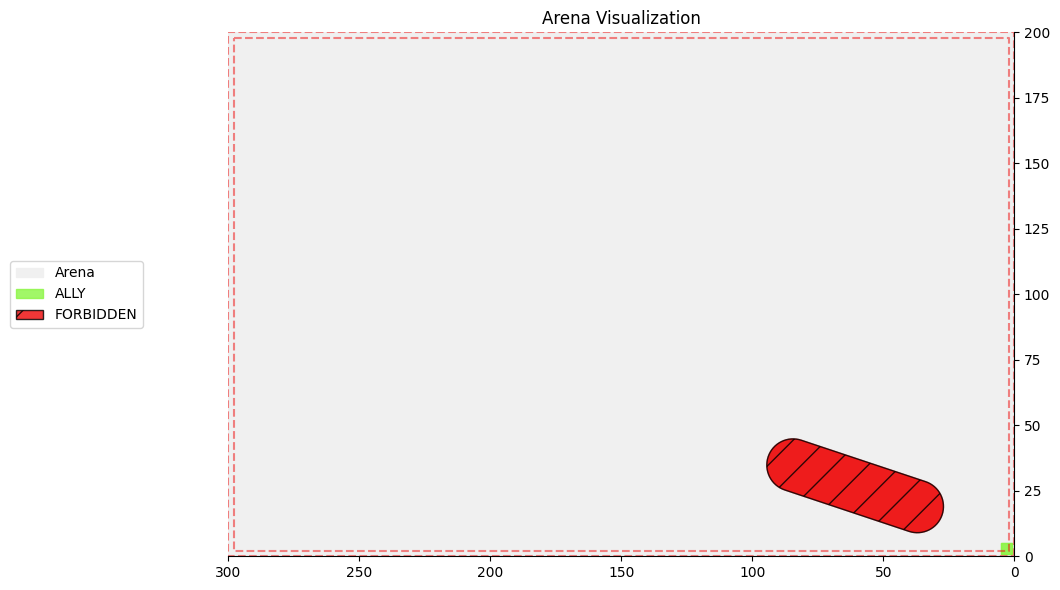

(<Axes: title={'center': 'Arena Visualization'}>,
 <Figure size 1200x600 with 1 Axes>)

In [4]:
arena.visualize()

# Path finding test

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import math
import random
import time

from matplotlib.animation import FuncAnimation
from config_loader import CONFIG

from geometry import (
    Point,
    MultiPoint,
    Polygon,
    MultiPolygon,
    LineString,
    BufferCapStyle,
    BufferJoinStyle,
    Geometry,
    create_straight_rectangle,
    prepare,
    distance,
    OrientedPoint,
    nearest_points,
    box,
)

# Import from common
from logger import Logger, LogLevels
from geometry import OrientedPoint

from arena import (
    ShowArena,
    BaseArenaZone,
    ZoneType,
    EnemyZone,
    StuffZone,
    ForbiddenZone,
    BlueReservedZone,
    YellowReservedZone,
    BorderZone,
)

from pathfinding.core.grid import Grid, GridNode

from path_finding import PathFinder

In [6]:
arena_logger = Logger(
    identifier="NewArena",
    decorator_level=LogLevels.INFO,
    print_log_level=LogLevels.DEBUG,
    file_log_level=LogLevels.DEBUG,
)
finder_logger = Logger(
    identifier="PathFinder",
    decorator_level=LogLevels.INFO,
    print_log_level=LogLevels.DEBUG,
    file_log_level=LogLevels.DEBUG,
)


chunk_size = 5

arena = ShowArena(
    logger=arena_logger,
    border_buffer=2,
    obstacle_buffer=5,
    chunk_size=chunk_size,
)
arena.set_team_color("y")

finder = PathFinder(
    logger=finder_logger,
    start=OrientedPoint(13, 14, 0.0),
    goal=OrientedPoint(52, 71, 0.0),
    grid_manager=arena.grid_manager,
    path_resolution=1,
)

finder.find_oriented_path(smooth_path=True)


15:59:31.380630 -> [  NewArena  ]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
15:59:31.385632 -> [ PathFinder ]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
15:59:31.388631 -> [ StuffZone  ]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
15:59:31.389637 -> [YellowRese..]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
15:59:31.391642 -> [BlueReserv..]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
15:59:31.394636 -> [ForbiddenZ..]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
15:59:31.410637 -> [  NewArena  ]  WARNING   | The border buffer is not a multiple of the chunk size -> the not walkable area will not be aligned with the grid
15:59:31.412637 -> [ BorderZone ]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
15:59:31.545642 -> [GridManager ]   DEBUG    | Function 

[POINT (13 14), theta: 0.0,
 POINT (13.207106781186548 13.207106781186548), theta: 0.0,
 POINT (13.914213562373096 13.914213562373096), theta: 0.0,
 POINT (14.621320343559642 14.621320343559642), theta: 0.0,
 POINT (15.32842712474619 15.32842712474619), theta: 0.0,
 POINT (16.035533905932738 16.035533905932738), theta: 0.0,
 POINT (16.742640687119284 16.742640687119284), theta: 0.0,
 POINT (17.44974746830583 17.44974746830583), theta: 0.0,
 POINT (17.5 17.5), theta: 0.0,
 POINT (18.05470019622523 18.332050294337844), theta: 0.0,
 POINT (18.609400392450457 19.164100588675687), theta: 0.0,
 POINT (19.164100588675687 19.99615088301353), theta: 0.0,
 POINT (19.718800784900917 20.828201177351374), theta: 0.0,
 POINT (20.273500981126144 21.660251471689218), theta: 0.0,
 POINT (20.828201177351374 22.49230176602706), theta: 0.0,
 POINT (20.833333333333332 22.5), theta: 0.0,
 POINT (21.14956109935017 23.448683298050515), theta: 0.0,
 POINT (21.46578886536701 24.397366596101026), theta: 0.0,
 PO

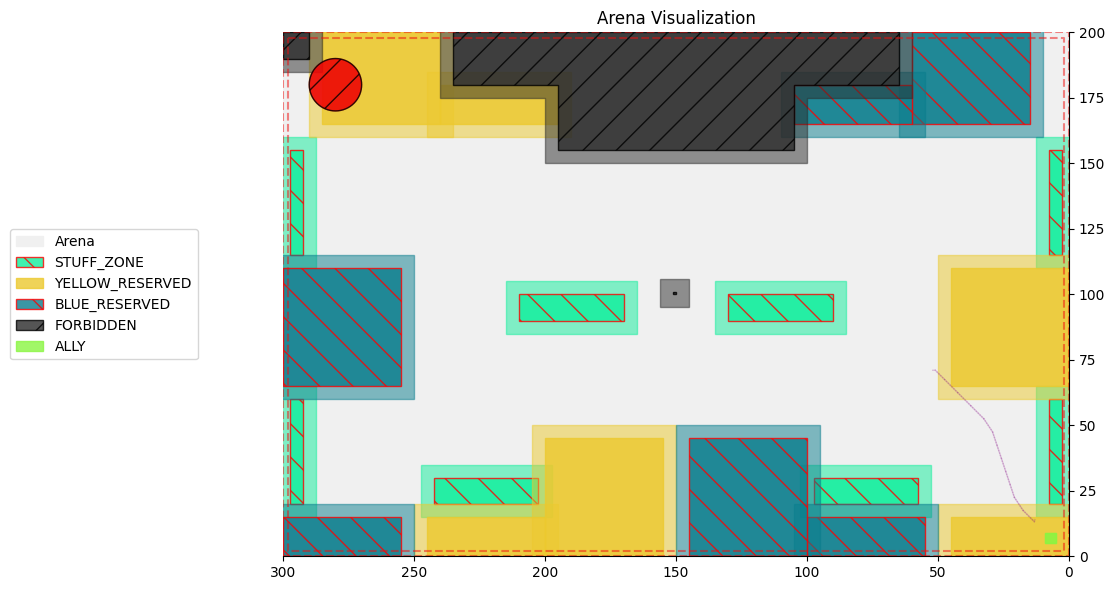

(<Axes: title={'center': 'Arena Visualization'}>,
 <Figure size 1200x600 with 1 Axes>)

In [7]:
arena.visualize(trajectory=finder.oriented_path_found)

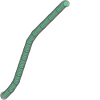

In [8]:
p = finder.oriented_path_found

multi_pi = MultiPoint(p)
multi_pi

In [9]:
r = nearest_points(finder.absolute_current_position, multi_pi)
r

(<POINT (13 14)>, <POINT (13 14)>)

In [10]:
indexx = None
for i in range(len(p)):
    if p[i].x == r[1].x and p[i].y == r[1].y:
        indexx = i
        break  
indexx

0

In [ ]:
final_path = None

# 3 cas
# 1. r[1] est le premier point du chemin -> on ajoute juste le point de départ au debut du path
if indexx == 0:
    final_path = [finder.absolute_current_position] + p
# 2. r[1] est entre 2 points du chemin -> on ajoute le point de départ et on supprime les points avant r[1]
elif indexx > 0:
        final_path = [finder.absolute_current_position] + p[indexx:]
final_path

[POINT (13 14), theta: 0.0,
 POINT (13 14), theta: 0.0,
 POINT (13.207106781186548 13.207106781186548), theta: 0.0,
 POINT (13.914213562373096 13.914213562373096), theta: 0.0,
 POINT (14.621320343559642 14.621320343559642), theta: 0.0,
 POINT (15.32842712474619 15.32842712474619), theta: 0.0,
 POINT (16.035533905932738 16.035533905932738), theta: 0.0,
 POINT (16.742640687119284 16.742640687119284), theta: 0.0,
 POINT (17.44974746830583 17.44974746830583), theta: 0.0,
 POINT (17.5 17.5), theta: 0.0,
 POINT (18.05470019622523 18.332050294337844), theta: 0.0,
 POINT (18.609400392450457 19.164100588675687), theta: 0.0,
 POINT (19.164100588675687 19.99615088301353), theta: 0.0,
 POINT (19.718800784900917 20.828201177351374), theta: 0.0,
 POINT (20.273500981126144 21.660251471689218), theta: 0.0,
 POINT (20.828201177351374 22.49230176602706), theta: 0.0,
 POINT (20.833333333333332 22.5), theta: 0.0,
 POINT (21.14956109935017 23.448683298050515), theta: 0.0,
 POINT (21.46578886536701 24.39736

In [12]:
p.index(r[1])

ValueError: <POINT (13 14)> is not in list

In [37]:
p

[POINT (12.5 12.5), theta: 0.0,
 POINT (13.207106781186548 13.207106781186548), theta: 0.0,
 POINT (13.914213562373096 13.914213562373096), theta: 0.0,
 POINT (14.621320343559642 14.621320343559642), theta: 0.0,
 POINT (15.32842712474619 15.32842712474619), theta: 0.0,
 POINT (16.035533905932738 16.035533905932738), theta: 0.0,
 POINT (16.742640687119284 16.742640687119284), theta: 0.0,
 POINT (17.44974746830583 17.44974746830583), theta: 0.0,
 POINT (17.5 17.5), theta: 0.0,
 POINT (18.05470019622523 18.332050294337844), theta: 0.0,
 POINT (18.609400392450457 19.164100588675687), theta: 0.0,
 POINT (19.164100588675687 19.99615088301353), theta: 0.0,
 POINT (19.718800784900917 20.828201177351374), theta: 0.0,
 POINT (20.273500981126144 21.660251471689218), theta: 0.0,
 POINT (20.828201177351374 22.49230176602706), theta: 0.0,
 POINT (20.833333333333332 22.5), theta: 0.0,
 POINT (21.14956109935017 23.448683298050515), theta: 0.0,
 POINT (21.46578886536701 24.397366596101026), theta: 0.0,